# Examen Bewegingen: Nokken
## Specificaties (Opgave 50)
De te ontwerpen nok moet volgende heffing kunnen realiseren :
- van 0° tot 120° : +10 mm
- van 120° tot 180° : +30 mm
- van 200° tot 240° : -40 mm

De equivalente massa en dempingsconstante van de volger (en bijhorende onderdelen) worden respectievelijk geschat op 5 kg en 0.062, terwijl het mechanisme volgende statische krachten moet uitoefenen:
- van 30° tot 110° : een konstante druk-kracht van 450 N
- van 110° tot 190° : een konstante druk-kracht van 950 N
- van 230° tot 300° : een lineair afnemende trek-kracht van 300 N tot 0 N 

De gevraagde cyclustijd voor de bewerking uitgevoerd door de volger is 0.10 sec.

In [ ]:
 # utility functions

from matplotlib import pyplot as plt
import numpy as np

gamma       = 0     # angle between lift and the gravity vector in degrees
m           = 5     # mass of the follower in kg
c           = 0.062 # damping coefficient in kg/s

dtheta      = 0.5   # angular resolution in degrees
range_theta = 360   # one full turn
n           = 1000  # angular velocity in rpm
theta_deg   = np.arange(0, range_theta, dtheta)

# kinematic arrays
lift    = np.zeros_like(theta_deg)
vel     = np.zeros_like(theta_deg)
acc     = np.zeros_like(theta_deg)

# a motion segment runs in one periodic cycle
# from "startangle" till "endangle",
# and moves from "startlift" till "endlift",
# with a given "motionlaw", and
# with interpolation resolution "dtheta":

def addMotionSegment(startangle,endangle,startlift,endlift,motionlaw,dtheta,n):
    assert startangle - endangle < 0, 'End angle should be bigger than start angle'
    start_index = int(startangle/dtheta)
    end_index = int(endangle/dtheta)
    beta = endangle - startangle
    omega = n*6 #angular velocity in deg/s
    L0 = startlift
    L1 = endlift
    x = np.linspace(0, 1, (end_index - start_index))
    if motionlaw == 1:  # dwell
        assert L1 - L0 == 0, 'The given input does not represent a dwell'
        lift[start_index:end_index] = L0 * np.ones_like(x)
        vel[start_index:end_index] = np.zeros_like(x)
        acc[start_index:end_index] = np.zeros_like(x)

    elif motionlaw == 2:  # 3rd order polynomial (minimal rms acceleration)
        L = L1 - L0
        lift[start_index:end_index] = L0 +  L * (3 * x**2 - 2 * x**3)
        vel[start_index:end_index] = L * (omega/beta) * (6 * x - 6 * x**2)
        acc[start_index:end_index] = L * (omega/beta)**2 * (6 - 12 * x)

    elif motionlaw == 3:  # harmonische
        L = L1 - L0
        lift[start_index:end_index] = L0 +  L * (1 - np.cos(np.pi * x)) / 2
        vel[start_index:end_index] = L * (omega/beta) * np.sin(np.pi * x) * np.pi / 2
        acc[start_index:end_index] = L * (omega/beta)**2 * np.cos(np.pi * x) * np.pi**2 / 2

    elif motionlaw == 4:  # volle cycloide
        L = L1 - L0
        lift[start_index:end_index] = L0 + L * (x - np.sin(2 * np.pi * x) / (2 * np.pi))
        vel[start_index:end_index] = L * (omega/beta) * (1 - np.cos(2 * np.pi * x))
        acc[start_index:end_index] = L * (omega/beta)**2 * 2 * np.pi * np.sin(2 * np.pi * x)

    elif motionlaw == 5:  # 5th degree poly
        L = L1 - L0
        lift[start_index:end_index] = L0 + L * (6 * x**5 - 15 * x**4 + 10 * x**3)
        vel[start_index:end_index] = L * (omega/beta) * (30 * x**4 - 60 * x**3 + 30 * x**2)
        acc[start_index:end_index] = L * (omega/beta)**2 * (120 * x**3 - 180 * x**2 + 60 * x)

    elif motionlaw == 6:  # 7th degree poly
        L = L1 - L0
        lift[start_index:end_index] = L0 + L * (-20 * x**7 + 70 * x**6 - 84 * x**5 + 35 * x**4)
        vel[start_index:end_index] = L * (omega/beta) * (-140 * x**6 + 420 * x**5 - 420 * x**4 + 140 * x**3)
        acc[start_index:end_index] = L * (omega/beta)**2 * (-840 * x**5 + 2100 * x**4 - 1680 * x**3 + 420 * x**2)

    return lift, vel, acc

def plotMotionLaw(t,lift,vel,acc):
    fig1, ax1 = plt.subplots(nrows=3,ncols=1,constrained_layout=True)
    fig1.suptitle("Lift")
    
    ax1[0].plot(t, lift)
    ax1[0].set_ylabel("Lift [mm]")
    ax1[0].set_xlabel('Theta [deg]')
    ax1[0].set_xlim([0,360])
    
    ax1[1].plot(t, vel)
    ax1[1].set_ylabel("Velocity [mm]/s")
    ax1[1].set_xlabel('Theta [deg]')
    ax1[1].set_xlim([0,360])
    
    ax1[2].plot(t, acc)
    ax1[2].set_ylabel("Acceleration [mm/s^2]")
    ax1[2].set_xlabel('Theta [deg]')
    ax1[2].set_xlim([0,360])

def undercutting(R0, lift, vel, acc, R_r):
    R_tot = R0 + lift
    rho = (R_tot**2 + vel**2)**(3/2) / (R_tot**2 + 2 * vel**2 - R_tot * acc)
    return np.min(rho) > R_r

def generateCamProfile(R0, ex, R_r, F_func, F_v0, k_v, c, m, gamma, lift, vel, acc,g=9.81):
    omega = n * 2 * np.pi / 60 # angular velocity in rad/s

    alpha = np.arctan((vel/omega - ex) / (np.sqrt(R0**2 - ex**2) + lift)) # angle of attack in radians
    normal = (F_func + F_v0 + k_v * lift + c * vel + m * acc + m * g * np.cos(gamma*np.pi/180)) / np.cos(alpha)
    assert np.max(np.abs(alpha)) < np.pi/6,           'The angle of attack should be less than 30 degrees (increase R0 or change ex)'
    assert np.min(normal) > 0,                        'The normal force should be positive for all angles (increase F_v0 or k_v)'
    assert not undercutting(R0, lift, vel, acc, R_r), 'Undercutting occurs (increase R0 or decrease R_r)'

    x_cam = (R0 + lift) * np.cos(theta_deg * np.pi / 180) - R_r * np.cos(theta_deg * np.pi / 180 + alpha)
    y_cam = (R0 + lift) * np.sin(theta_deg * np.pi / 180) - R_r * np.sin(theta_deg * np.pi / 180 + alpha)

    return x_cam, y_cam

def plotCamProfile(R0, ex, R_r, lift, x_cam, y_cam):
    theta_rad = theta_deg * np.pi / 180
    R_pitch = R0 + lift

    # steekkromme
    x_pitch = R_pitch * np.cos(theta_rad)
    y_pitch = R_pitch * np.sin(theta_rad)

    # steekcirkel
    phi = np.linspace(0, 2 * np.pi, 500)
    x_base = R0 * np.cos(phi)
    y_base = R0 * np.sin(phi)

    # basiscirkel
    phi = np.linspace(0, 2 * np.pi, 500)
    x_base = R_r * np.cos(phi)
    y_base = R_r * np.sin(phi)

    fig, ax = plt.subplots(figsize=(8, 8))
    ax.plot(x_cam, y_cam, 'b-', linewidth=2, label='Nokprofiel')
    ax.plot(x_pitch, y_pitch, 'r--', linewidth=1, label='Steekkromme')
    ax.plot(x_base, y_base, 'k:', linewidth=1, label='Basiscirkel')
    ax.plot(0, 0, 'k+', markersize=10)

    if ex != 0:
        ax.axhline(y=ex, color='gray', linestyle='-.', linewidth=0.5, label=f'Excentriciteit e={ex}')

    ax.set_aspect('equal')
    ax.set_xlabel('x [mm]')
    ax.set_ylabel('y [mm]')
    ax.set_title('Nokprofiel met volgrol')
    ax.legend(loc='upper right')
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

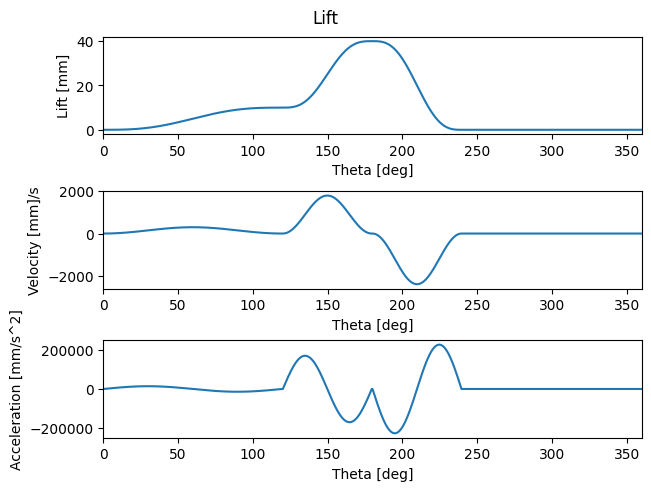

In [30]:
n_initial = 300  # initial angular velocity in rpm

#Segment 1
startangle = 0
endangle = 120
startlift = 0
endlift = 10
motionlaw = 4

# Add the segment to the motion law
lift, vel, acc = addMotionSegment(startangle,endangle,startlift,endlift,motionlaw,dtheta,n_initial)

#Segment 2
startangle = 120
endangle = 180
startlift = 10
endlift = 40
motionlaw = 4

# Add the segment to the motion law
lift, vel, acc = addMotionSegment(startangle,endangle,startlift,endlift,motionlaw,dtheta,n_initial)

#Segment 3
startangle = 180
endangle = 240
startlift = 40
endlift = 0
motionlaw = 4

# Add the segment to the motion law
lift, vel, acc = addMotionSegment(startangle,endangle,startlift,endlift,motionlaw,dtheta,n_initial)

# Plot the motion law
plotMotionLaw(theta_deg,lift,vel,acc)

plt.show()

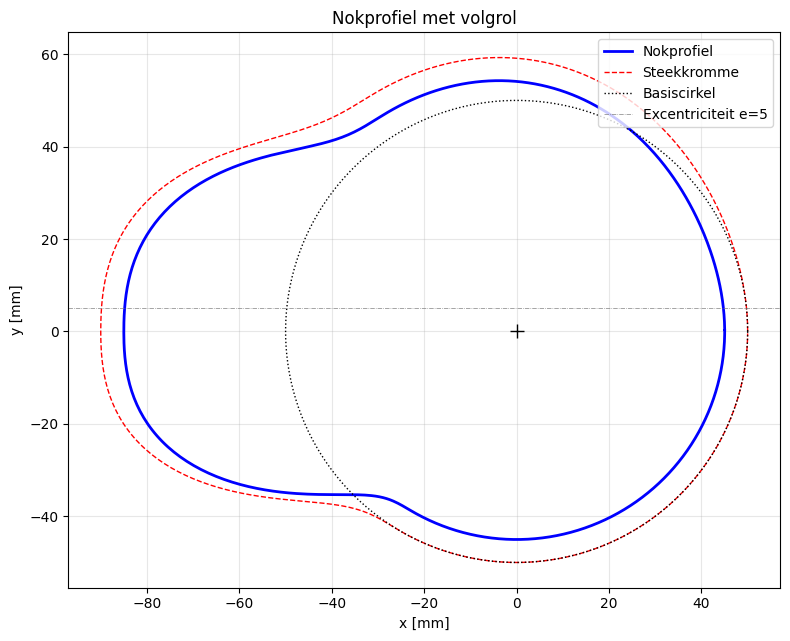

In [ ]:

R0 = 50  # base circle radius in mm
e = 5    # excentricity in mm
R_r = 5  # roller radius in mm
x_cam, y_cam = generateCamProfile(R0=R0, ex=e, R_r=R_r, F_func=10, F_v0=100000000, k_v=1000000, c=0.062, m=5, gamma=0, lift=lift, vel=vel, acc=acc)
plotCamProfile(R0=R0, ex=e, R_r=R_r, lift=lift, x_cam=x_cam, y_cam=y_cam)